# GPU-Accelerated AutoML Framework for Machine Learning Applications on CSV Data using RAPIDS

The project focuses on developing a GPU-accelerated AutoML framework that automates the entire machine learning pipeline for CSV-based tabular datasets using RAPIDS libraries such as cuDF and cuML. It enables users to upload structured data from domains like healthcare, finance, or logistics, and then seamlessly performs data ingestion, preprocessing (handling missing values, encoding, normalization), feature engineering (selection and dimensionality reduction), and automatic problem identification (classification or regression). The system trains multiple machine learning models-including Logistic Regression, Random Forest, XGBoost, KNN, and SVM-while leveraging GPU acceleration to significantly reduce computation time, and applies hyperparameter tuning through techniques like Grid Search or Random Search. Finally, it evaluates models using appropriate metrics (such as Accuracy, F1-score, or RMSE) and outputs the best-performing model along with performance insights, making the solution scalable, efficient, and accessible even to users with minimal ML expertise

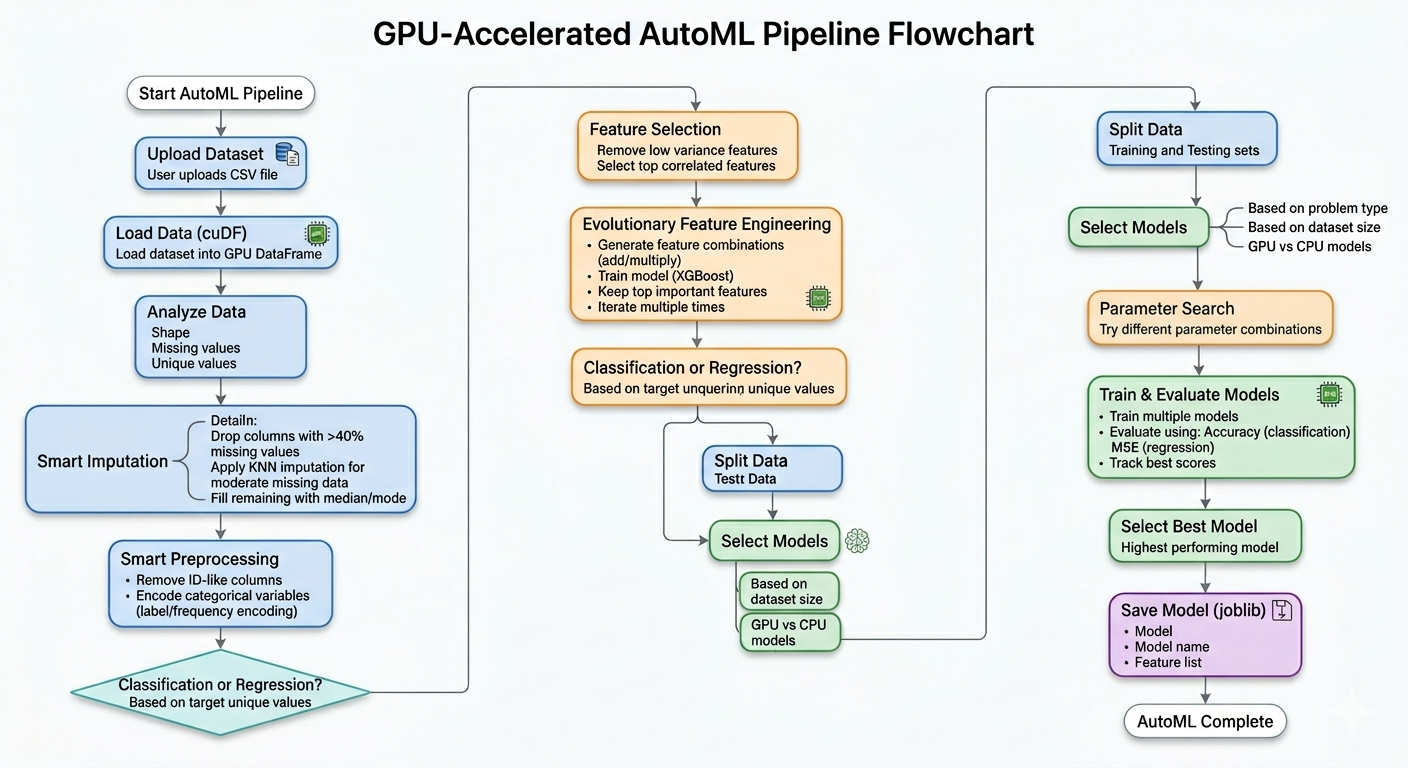

### Import Libraries

Here, we install GPU-based libraries and import different ML models and tools so we can train and evaluate models much faster.

In [1]:
!pip install --extra-index-url=https://pypi.nvidia.com cudf-cu12 cuml-cu12
!pip uninstall -y xgboost lightgbm && pip install --extra-index-url=https://pypi.nvidia.com xgboost && pip install lightgbm --config-settings=cmake.define.USE_GPU=ON
import cudf
import cupy as cp

from cuml.model_selection import train_test_split

from cuml.linear_model import LogisticRegression
from cuml.ensemble import RandomForestClassifier
from cuml.neighbors import KNeighborsClassifier
from cuml.svm import SVC
from cuml.naive_bayes import GaussianNB

from cuml.linear_model import LinearRegression
from cuml.ensemble import RandomForestRegressor
from cuml.neighbors import KNeighborsRegressor
from cuml.svm import SVR


from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.ensemble import RandomForestClassifier as SkRF
from sklearn.base import clone

import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

from sklearn.metrics import accuracy_score, mean_squared_error

import itertools
import random

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
Found existing installation: xgboost 3.2.0
Uninstalling xgboost-3.2.0:
  Successfully uninstalled xgboost-3.2.0
Found existing installation: lightgbm 4.6.0
Uninstalling lightgbm-4.6.0:
  Successfully uninstalled lightgbm-4.6.0
Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 41.3 MB/s eta 0:00:00


### Upload and Load Dataset

Here, we upload a dataset file and load it into a GPU DataFrame using cuDF, then display its name and shape.

In [2]:
from google.colab import files

def load_data():
    uploaded = files.upload()
    file_name = next(iter(uploaded))

    df = cudf.read_csv(file_name)

    print(f"Loaded: {file_name}")
    print("Shape:", df.shape)

    return df

### Basic Data Analysis

Here, we analyze the dataset by checking its size, missing values ratio, and number of unique values in each column.

In [3]:
def analyze_data(df):
    info = {}
    info['shape'] = df.shape
    info['missing_ratio'] = df.isnull().sum() / len(df)
    info['nunique'] = df.nunique()
    return info

### Smart Missing Value Handling

Here, we handle missing data by dropping highly incomplete columns, using KNN for moderate missing values, and filling the rest with median or mode.

In [4]:
def smart_imputation(df):

    pdf = df.to_pandas()
    missing_ratio = pdf.isnull().mean()

    # Drop high missing columns
    drop_cols = missing_ratio[missing_ratio > 0.4].index
    pdf = pdf.drop(columns=drop_cols)

    # Numeric columns for KNN
    numeric_cols = pdf.select_dtypes(include=[np.number]).columns

    knn_cols = [col for col in numeric_cols
                if 0.05 < missing_ratio[col] <= 0.4]

    if len(knn_cols) > 0:
        k = min(5, int(np.sqrt(len(pdf))))
        imputer = KNNImputer(n_neighbors=k)
        pdf[knn_cols] = imputer.fit_transform(pdf[knn_cols])

    # Fill remaining
    for col in pdf.columns:
        if pdf[col].isnull().sum() > 0:
            if pd.api.types.is_numeric_dtype(pdf[col]):
                pdf[col] = pdf[col].fillna(pdf[col].median())
            else:
                pdf[col] = pdf[col].fillna(pdf[col].mode()[0])

    return cudf.from_pandas(pdf)

### Smart Data Preprocessing

Here, we clean the data by removing ID-like columns and converting categorical features into numeric form using encoding techniques.

In [5]:
def smart_preprocess(df):

    cols = list(df.columns)

    for col in cols:

        # Drop ID-like columns
        if df[col].nunique() == len(df):
            df = df.drop(columns=[col])
            continue

        # Encode categorical
        if df[col].dtype == 'object':

            if df[col].nunique() < 10:
                df[col] = df[col].astype('category').cat.codes
            else:
                freq = df[col].value_counts()
                df[col] = df[col].map(freq)

    return df

### Dataset Splitting & Problem Detection

Here, we split the data into features and target, and automatically decide if it’s a classification or regression problem.

In [6]:
def split_data(df):

    target_col = df.columns[-1]

    X = df.drop(columns=[target_col])
    y = df[target_col]


    if y.dtype != 'float':
        y = y.astype('category').cat.codes

    # Detect problem type
    problem = "classification" if y.nunique() < 50 else "regression"

    return X, y, problem

### Top Feature Selection

Here, we remove low-variance features and select the most important ones based on their correlation with the target variable.

In [7]:
def select_top_features(X, y, k=15):

    numeric_cols = X.select_dtypes(include=['number']).columns
    X_num = X[numeric_cols]

    X_num = X_num.loc[:, X_num.var() > 0.01]

    df = X_num.copy()
    df['target'] = y

    corr_matrix = df.corr()
    target_corr = corr_matrix['target'].drop('target').abs()

    top_features = (
        target_corr.nlargest(min(k, len(target_corr)))
        .index
        .to_pandas()
        .tolist()
    )

    return X[top_features]

### Feature Combination Generation

Here, we create new features by combining existing ones through addition and multiplication to capture more patterns in the data.

In [8]:
def generate_combinations(X):

    X_new = X.copy()

    cols = list(X.columns)

    combs = list(itertools.combinations(cols, 2))
    combs = random.sample(combs, min(100, len(combs)))

    for f1, f2 in combs:
        X_new[f"{f1}_mul_{f2}"] = X[f1] * X[f2]
        X_new[f"{f1}_add_{f2}"] = X[f1] + X[f2]

    return X_new

### Remove Redundant Features

Here, we remove features with very low variance since they don’t contribute useful information to the model.

In [9]:
def remove_redundant_features(X):
    return X.loc[:, X.var() > 0.01]

### Evolutionary Feature Engineering

Here, we iteratively create new features, train a model to evaluate their importance, and keep only the best ones, improving the feature set over multiple steps.

In [10]:
def evolutionary_features(X, y, problem="classification", iterations=2):

    # Try GPU, fallback to CPU
    try:
        tree_method = "gpu_hist"
        predictor = "gpu_predictor"
    except:
        tree_method = "hist"
        predictor = None

    for i in range(iterations):

        X = generate_combinations(X)
        X = remove_redundant_features(X)

        if problem == "classification":
            model = XGBClassifier(
                tree_method=tree_method,
                predictor=predictor,
                n_estimators=100,
                max_depth=6,
                eval_metric='logloss'
            )
        else:
            model = XGBRegressor(
                tree_method=tree_method,
                predictor=predictor,
                n_estimators=100,
                max_depth=6
            )

        try:
            model.fit(X, y)
        except:
            print("⚠️ GPU not available, switching to CPU...")
            model = model.__class__(
                tree_method="hist",
                n_estimators=100,
                max_depth=6
            )
            model.fit(X, y)

        importances = model.feature_importances_
        top_idx = np.argsort(importances)[-20:]

        X = X.iloc[:, top_idx]

        print(f"Iteration {i+1}: {X.shape[1]} features")

    return X

### Model Selection with GPU Optimization

Here, we select suitable ML models based on the problem type and dataset size, while automatically using GPU acceleration if available for better performance.

In [11]:
def get_models(problem, size):

    models = {}


    def is_gpu_available():
        try:
            import cupy as cp
            _ = cp.zeros((1,))
            return True
        except:
            return False

    GPU_AVAILABLE = is_gpu_available()


    if GPU_AVAILABLE:
        xgb_params = {
            "tree_method": "hist",
            "device": "cuda"
        }
    else:
        xgb_params = {
            "tree_method": "hist",
            "device": "cpu"
        }


    lgbm_params = {
        "device": "gpu" if GPU_AVAILABLE else "cpu",
        "verbose": -1,
        "min_data_in_leaf": 1
    }


    small_data = size < 1000


    if problem == "classification":

        if small_data:

            models["knn"] = KNeighborsClassifier()
            models["logistic"] = LogisticRegression(max_iter=1000)
            models["svm"] = SVC()

        else:

            models["rf"] = RandomForestClassifier(
                max_depth=10 if GPU_AVAILABLE else 10
            )
            models["knn"] = KNeighborsClassifier()
            models["logistic"] = LogisticRegression(max_iter=1000)
            models["svm"] = SVC()


            models["xgboost"] = XGBClassifier(
                **xgb_params,
                eval_metric="logloss",
                n_estimators=100,
                max_depth=6
            )


            models["lightgbm"] = LGBMClassifier(
                **lgbm_params,
                n_estimators=100,
                max_depth=6
            )


    elif problem == "regression":

        if small_data:
            models["knn"] = KNeighborsRegressor()
            models["linear"] = LinearRegression()
            models["svm"] = SVR()

        else:
            models["rf"] = RandomForestRegressor(max_depth=10)
            models["knn"] = KNeighborsRegressor()
            models["linear"] = LinearRegression()
            models["svm"] = SVR()

            models["xgboost"] = XGBRegressor(
                **xgb_params,
                n_estimators=100,
                max_depth=6
            )

            models["lightgbm"] = LGBMRegressor(
                **lgbm_params,
                n_estimators=100,
                max_depth=6
            )

    else:
        raise ValueError("Problem must be 'classification' or 'regression'")

    return models

### Hyperparameter Tuning

Here, we define different parameter combinations for each model so we can tune them and find the best performance.

In [12]:
def get_param_spaces(problem):

    if problem == "classification":
        return {
            "rf": {
                "max_depth": [5, 10],
                "n_estimators": [50, 100]
            },
            "knn": {
                "n_neighbors": [3, 5, 7]
            },
            "logistic": {
                "C": [0.1, 1, 10]
            },
            "svm": {
                "C": [0.5, 1, 2]
            },
            "xgboost": {
                "max_depth": [4, 6, 8],
                "n_estimators": [100, 200]
            },
            "lightgbm": {
                "max_depth": [4, 6, 8],
                "n_estimators": [100, 200]
            }
        }

    else:
        return {
            "rf": {
                "max_depth": [5, 10],
                "n_estimators": [50, 100]
            },
            "knn": {
                "n_neighbors": [3, 5, 7]
            },
            "linear": {},
            "svm": {
                "C": [0.5, 1, 2]
            },
            "xgboost": {
                "max_depth": [4, 6, 8],
                "n_estimators": [100, 200]
            },
            "lightgbm": {
                "max_depth": [4, 6, 8],
                "n_estimators": [100, 200]
            }
        }

### Model Training and Evaluation

Here, we train multiple models with different parameter combinations, evaluate their performance, and keep the best-performing version of each model.

In [13]:
def train_evaluate(models, X_train, X_test, y_train, y_test, problem, n_trials=3):

    results = {}
    best_models = {}

    param_spaces = get_param_spaces(problem)

    y_true = y_test.to_pandas() if hasattr(y_test, "to_pandas") else y_test

    for name, model in models.items():

        best_score = -float("inf")
        best_model = None

        param_grid = param_spaces.get(name, {})

        if param_grid:
            keys, values = zip(*param_grid.items())
            all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            trials = random.sample(all_combinations, min(n_trials, len(all_combinations)))
        else:
            trials = [{}]

        for params in trials:

            try:
                model_instance = clone(model)
                model_instance.set_params(**params)

                if name in ["xgboost", "lightgbm", "adaboost"]:
                    X_tr = X_train.to_pandas()
                    y_tr = y_train.to_pandas()
                    X_te = X_test.to_pandas()
                else:
                    X_tr, y_tr, X_te = X_train, y_train, X_test

                if name in ["knn", "svm", "logistic"]:
                    scaler = StandardScaler()
                    X_tr_np = X_tr.to_numpy() if hasattr(X_tr, "to_numpy") else X_tr
                    X_te_np = X_te.to_numpy() if hasattr(X_te, "to_numpy") else X_te
                    X_tr = scaler.fit_transform(X_tr_np)
                    X_te = scaler.transform(X_te_np)

                model_instance.fit(X_tr, y_tr)
                preds = model_instance.predict(X_te)

                if hasattr(preds, "to_pandas"):
                    preds = preds.to_pandas()

                if problem == "classification":
                    score = accuracy_score(y_true, preds)
                else:
                    score = -mean_squared_error(y_true, preds)

                if score > best_score:
                    best_score = score
                    best_model = model_instance

            except Exception as e:
                print(f"⚠️ Skipping {name} with params {params} due to error: {e}")
                continue

        if best_model is None:
            print(f"❌ {name} failed completely.")
            results[name] = None
            best_models[name] = None
        else:
            results[name] = best_score
            best_models[name] = best_model
            print(f"{name}: Best Score = {best_score:.4f}")

    return results, best_models

### End-to-End AutoML Pipeline

Here, we run the complete pipeline-from loading data to preprocessing, feature engineering, model training, and finally selecting and saving the best model automatically.

In [14]:
import joblib

def run_automl():

    df = load_data()

    analyze_data(df)

    df = smart_imputation(df)
    df = smart_preprocess(df)

    X, y, problem = split_data(df)

    # Feature Engineering
    X = select_top_features(X, y)
    X = evolutionary_features(X, y, problem=problem)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y)

    # Get models
    models = get_models(problem, len(df))

    # Train + Tune
    results, best_models = train_evaluate(
        models, X_train, X_test, y_train, y_test, problem
    )

    # Select best model
    valid_results = {k: v for k, v in results.items() if v is not None}

    if not valid_results:
      raise ValueError("❌ All models failed!")

    best_model_name = max(valid_results, key=valid_results.get)
    best_model = best_models[best_model_name]

    print("\nBest Model:", best_model_name)
    print("Best Score:", results[best_model_name])

    # Save the best model
    joblib.dump({
        "model": best_model,
        "model_name": best_model_name,
        "features": list(X.columns)
    }, "best_automl_model.pkl")

    print("Model saved as best_automl_model.pkl")

    return best_model, best_model_name, results

# Runtime:

In [15]:
run_automl()

Saving cybersecurity.csv to cybersecurity.csv
Loaded: cybersecurity.csv
Shape: (10000, 12)
⚠️ GPU not available, switching to CPU...
Iteration 1: 20 features
⚠️ GPU not available, switching to CPU...
Iteration 2: 20 features
rf: Best Score = 0.9608
knn: Best Score = 0.9560
logistic: Best Score = 0.9568
svm: Best Score = 0.9556


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [18:05:14] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


xgboost: Best Score = 0.9612
lightgbm: Best Score = 0.9492

Best Model: xgboost
Best Score: 0.9612
Model saved as best_automl_model.pkl


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device='cuda', early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=4, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=200, n_jobs=None,
               num_parallel_tree=None, ...),
 'xgboost',
 {'rf': 0.9608,
  'knn': 0.956,
  'logistic': 0.9568,
  'svm': 0.9556,
  'xgboost': 0.9612,
  'lightgbm': 0.9492})